# Multi-Model Text Classification Pipeline

Training 12 models using GloVe and TF-IDF representations with SVM and Linear Regression across 3 CSV files.

**Models to train:**
- 3 CSV files × 2 text representations × 2 classifiers = 12 base models

In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, mean_squared_error, r2_score, roc_auc_score, ConfusionMatrixDisplay
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
import os 
warnings.filterwarnings('ignore')

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


## 1. Load CSV Files

In [11]:
# Define paths to the new datasets from Task 2
csv_files = {
    'punc_lower_stop_spell_lemma_tags': 'cleaned_remove_punctuation_lowercase_remove_stopwords_fix_spelling_lemmatize_extract_tags.csv',
    'num_punc_lower_stop_lemma_tags': 'cleaned_remove_numbers_remove_punctuation_lowercase_remove_stopwords_lemmatize_extract_tags.csv',
    'urls_html_mentions_tags': 'cleaned_remove_urls_remove_html_remove_mentions_remove_hashtags_remove_punctuation_extract_tags.csv',
    'urls_punc_lower_stop_lemma_tags': 'cleaned_remove_urls_remove_punctuation_lowercase_remove_stopwords_lemmatize_extract_tags.csv'
}

def rating_to_sentiment(rating):
    if rating <= 5:
        return "negative"
    elif rating <= 7:
        return "neutral"
    else:
        return "positive"


datasets = {}
for name, filename in csv_files.items():
    filepath = os.path.join(filename)
    df = pd.read_csv(filepath)
    
    # Handle missing ground_truth by deriving it from rating
    if 'ground_truth' not in df.columns and 'rating' in df.columns:
        df['ground_truth'] = df['rating'].apply(rating_to_sentiment)
    
    # Ensure cleaned_text exists and handle NaNs
    if 'cleaned_text' in df.columns:
        df = df.dropna(subset=['cleaned_text', 'ground_truth'])
    
    datasets[name] = df
    print(f"\n{name}:")
    print(f"  Shape: {df.shape}")
    print(f"  Columns: {df.columns.tolist()}")
    if 'ground_truth' in df.columns:
        print(f"  Target distribution:\n{df['ground_truth'].value_counts()}")
    print(f"  Total Missing values: {df.isnull().sum().sum()}")

print("\n✓ All datasets loaded and prepared successfully")



punc_lower_stop_spell_lemma_tags:
  Shape: (237, 11)
  Columns: ['movie_title', 'genres', 'content', 'rating', 'movie_id', 'review_id', 'author', 'created_at', 'cleaned_text', 'category', 'ground_truth']
  Target distribution:
ground_truth
neutral     79
negative    79
positive    79
Name: count, dtype: int64
  Total Missing values: 0

num_punc_lower_stop_lemma_tags:
  Shape: (237, 11)
  Columns: ['movie_title', 'genres', 'content', 'rating', 'movie_id', 'review_id', 'author', 'created_at', 'cleaned_text', 'category', 'ground_truth']
  Target distribution:
ground_truth
neutral     79
negative    79
positive    79
Name: count, dtype: int64
  Total Missing values: 0

urls_html_mentions_tags:
  Shape: (237, 11)
  Columns: ['movie_title', 'genres', 'content', 'rating', 'movie_id', 'review_id', 'author', 'created_at', 'cleaned_text', 'category', 'ground_truth']
  Target distribution:
ground_truth
neutral     79
negative    79
positive    79
Name: count, dtype: int64
  Total Missing values:

## 2. Prepare Data for Modeling

In [12]:
# Prepare data for each dataset
data_splits = {}

for name, df in datasets.items():
    X = df['cleaned_text'].values
    y = df['ground_truth'].values
    
    # Encode labels (assuming binary classification: positive/negative)
    label_mapping = {label: idx for idx, label in enumerate(np.unique(y))}
    y_encoded = np.array([label_mapping[label] for label in y])
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
    )
    
    data_splits[name] = {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'label_mapping': label_mapping,
        'reverse_mapping': {v: k for k, v in label_mapping.items()}
    }
    
    print(f"{name}:")
    print(f"  Training set: {len(X_train)} samples")
    print(f"  Test set: {len(X_test)} samples")
    print(f"  Label mapping: {label_mapping}\n")

print("✓ Data prepared and split into train/test sets")

punc_lower_stop_spell_lemma_tags:
  Training set: 189 samples
  Test set: 48 samples
  Label mapping: {'negative': 0, 'neutral': 1, 'positive': 2}

num_punc_lower_stop_lemma_tags:
  Training set: 189 samples
  Test set: 48 samples
  Label mapping: {'negative': 0, 'neutral': 1, 'positive': 2}

urls_html_mentions_tags:
  Training set: 189 samples
  Test set: 48 samples
  Label mapping: {'negative': 0, 'neutral': 1, 'positive': 2}

urls_punc_lower_stop_lemma_tags:
  Training set: 189 samples
  Test set: 48 samples
  Label mapping: {'negative': 0, 'neutral': 1, 'positive': 2}

✓ Data prepared and split into train/test sets


## 3. Text Representation: GloVe Embeddings

In [13]:
def load_glove_embeddings(glove_file):
    """Load GloVe embeddings from file"""
    embeddings_index = {}
    with open(glove_file, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs
    return embeddings_index

def create_glove_embeddings(texts, embeddings_index, embedding_dim=100):
    """Create GloVe embeddings from texts"""
    embeddings = []
    for text in texts:
        words = text.split()
        valid_vectors = [embeddings_index[word] for word in words if word in embeddings_index]
        
        if valid_vectors:
            doc_vector = np.mean(valid_vectors, axis=0)
        else:
            doc_vector = np.zeros(embedding_dim)
        embeddings.append(doc_vector)
    
    return np.array(embeddings)

# Load GloVe embeddings
print("Loading GloVe embeddings from glove.6B.100d...")
glove_embeddings = load_glove_embeddings(r'C:\Users\Aliel\Desktop\Task_2\final_data\glove.6B.100d.txt')
print(f"✓ Loaded {len(glove_embeddings)} word vectors")

# Create GloVe embeddings for each dataset
glove_representations = {}

for name, splits in data_splits.items():
    print(f"\nCreating GloVe embeddings for {name}...")
    
    # Create embeddings for training and test data
    train_embeddings = create_glove_embeddings(splits['X_train'], glove_embeddings, embedding_dim=100)
    test_embeddings = create_glove_embeddings(splits['X_test'], glove_embeddings, embedding_dim=100)
    
    glove_representations[name] = {
        'X_train': train_embeddings,
        'X_test': test_embeddings,
        'embeddings_index': glove_embeddings
    }
    
    print(f"  Train shape: {train_embeddings.shape}")
    print(f"  Test shape: {test_embeddings.shape}")

print("\n✓ GloVe embeddings created for all datasets")

Loading GloVe embeddings from glove.6B.100d...
✓ Loaded 400000 word vectors

Creating GloVe embeddings for punc_lower_stop_spell_lemma_tags...
  Train shape: (189, 100)
  Test shape: (48, 100)

Creating GloVe embeddings for num_punc_lower_stop_lemma_tags...
  Train shape: (189, 100)
  Test shape: (48, 100)

Creating GloVe embeddings for urls_html_mentions_tags...
  Train shape: (189, 100)
  Test shape: (48, 100)

Creating GloVe embeddings for urls_punc_lower_stop_lemma_tags...
  Train shape: (189, 100)
  Test shape: (48, 100)

✓ GloVe embeddings created for all datasets


## 4. Text Representation: TF-IDF

In [14]:
from sklearn.preprocessing import StandardScaler

# Create TF-IDF vectorizer for each dataset
tfidf_representations = {}

for name, splits in data_splits.items():
    print(f"Creating TF-IDF for {name}...")
    
    # Create and fit TF-IDF vectorizer
    vectorizer = TfidfVectorizer(max_features=1000, min_df=2, max_df=0.8)
    X_train_tfidf = vectorizer.fit_transform(splits['X_train'])
    X_test_tfidf = vectorizer.transform(splits['X_test'])
    
    # Scale sparse TF-IDF features (with_mean=False to preserve sparsity)
    scaler = StandardScaler(with_mean=False)
    X_train_tfidf_scaled = scaler.fit_transform(X_train_tfidf)
    X_test_tfidf_scaled = scaler.transform(X_test_tfidf)
    
    tfidf_representations[name] = {
        'X_train': X_train_tfidf_scaled,
        'X_test': X_test_tfidf_scaled,
        'vectorizer': vectorizer,
        'scaler': scaler
    }
    
    print(f"  Train shape: {X_train_tfidf_scaled.shape}")
    print(f"  Test shape: {X_test_tfidf_scaled.shape}")
    print(f"  Vocabulary size: {len(vectorizer.get_feature_names_out())}\n")

print("✓ TF-IDF vectorization completed for all datasets (scaled with sparse awareness)")

Creating TF-IDF for punc_lower_stop_spell_lemma_tags...
  Train shape: (189, 1000)
  Test shape: (48, 1000)
  Vocabulary size: 1000

Creating TF-IDF for num_punc_lower_stop_lemma_tags...
  Train shape: (189, 1000)
  Test shape: (48, 1000)
  Vocabulary size: 1000

Creating TF-IDF for urls_html_mentions_tags...
  Train shape: (189, 1000)
  Test shape: (48, 1000)
  Vocabulary size: 1000

Creating TF-IDF for urls_punc_lower_stop_lemma_tags...
  Train shape: (189, 1000)
  Test shape: (48, 1000)
  Vocabulary size: 1000

✓ TF-IDF vectorization completed for all datasets (scaled with sparse awareness)


## 5. Train SVM Models

In [15]:
from sklearn.preprocessing import label_binarize

# Dictionary to store all models and results
svm_models = {}
svm_results = []
svm_confusion_matrices = {}
svm_roc_auc = {}

for dataset_name in data_splits.keys():
    y_train = data_splits[dataset_name]['y_train']
    y_test = data_splits[dataset_name]['y_test']
    num_classes = len(np.unique(y_test))
    
    # ============ SVM with GloVe ============
    print(f"\nTraining SVM + GloVe for {dataset_name}...")
    X_train_glove = glove_representations[dataset_name]['X_train']
    X_test_glove = glove_representations[dataset_name]['X_test']
    
    svm_glove = SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced', random_state=42, probability=True)
    svm_glove.fit(X_train_glove, y_train)
    y_pred_glove = svm_glove.predict(X_test_glove)
    y_proba_glove = svm_glove.predict_proba(X_test_glove)
    
    acc_glove = accuracy_score(y_test, y_pred_glove)
    prec_glove = precision_score(y_test, y_pred_glove, average='weighted', zero_division=0)
    rec_glove = recall_score(y_test, y_pred_glove, average='weighted', zero_division=0)
    f1_glove = f1_score(y_test, y_pred_glove, average='weighted', zero_division=0)
    
    # Confusion Matrix
    cm_glove = confusion_matrix(y_test, y_pred_glove)
    svm_confusion_matrices[f'{dataset_name}_glove_svm'] = cm_glove
    
    # ROC-AUC (One-vs-Rest for multiclass)
    if num_classes == 2:
        roc_auc_glove = roc_auc_score(y_test, y_proba_glove[:, 1])
    else:
        y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
        roc_auc_glove = roc_auc_score(y_test_bin, y_proba_glove, average='weighted', multi_class='ovr')
    svm_roc_auc[f'{dataset_name}_glove_svm'] = roc_auc_glove
    
    svm_models[f'{dataset_name}_glove_svm'] = {
        'model': svm_glove,
        'type': 'SVM',
        'representation': 'GloVe'
    }
    
    svm_results.append({
        'Dataset': dataset_name,
        'Model': 'SVM + GloVe',
        'Accuracy': acc_glove,
        'Precision': prec_glove,
        'Recall': rec_glove,
        'F1-Score': f1_glove,
        'ROC-AUC': roc_auc_glove
    })
    
    print(f"  Accuracy: {acc_glove:.4f}, F1: {f1_glove:.4f}, ROC-AUC: {roc_auc_glove:.4f}")
    
    # ============ SVM with TF-IDF ============
    print(f"Training SVM + TF-IDF for {dataset_name}...")
    X_train_tfidf = tfidf_representations[dataset_name]['X_train']
    X_test_tfidf = tfidf_representations[dataset_name]['X_test']
    
    # Use linear kernel for sparse TF-IDF (more suitable), high C to force fitting
    svm_tfidf = SVC(kernel='linear', C=100.0, class_weight='balanced', random_state=42, max_iter=5000, probability=True)
    svm_tfidf.fit(X_train_tfidf, y_train)
    y_pred_tfidf = svm_tfidf.predict(X_test_tfidf)
    y_proba_tfidf = svm_tfidf.predict_proba(X_test_tfidf)
    
    acc_tfidf = accuracy_score(y_test, y_pred_tfidf)
    prec_tfidf = precision_score(y_test, y_pred_tfidf, average='weighted', zero_division=0)
    rec_tfidf = recall_score(y_test, y_pred_tfidf, average='weighted', zero_division=0)
    f1_tfidf = f1_score(y_test, y_pred_tfidf, average='weighted', zero_division=0)
    
    # Confusion Matrix
    cm_tfidf = confusion_matrix(y_test, y_pred_tfidf)
    svm_confusion_matrices[f'{dataset_name}_tfidf_svm'] = cm_tfidf
    
    # ROC-AUC (One-vs-Rest for multiclass)
    if num_classes == 2:
        roc_auc_tfidf = roc_auc_score(y_test, y_proba_tfidf[:, 1])
    else:
        y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
        roc_auc_tfidf = roc_auc_score(y_test_bin, y_proba_tfidf, average='weighted', multi_class='ovr')
    svm_roc_auc[f'{dataset_name}_tfidf_svm'] = roc_auc_tfidf
    
    svm_models[f'{dataset_name}_tfidf_svm'] = {
        'model': svm_tfidf,
        'type': 'SVM',
        'representation': 'TF-IDF'
    }
    
    svm_results.append({
        'Dataset': dataset_name,
        'Model': 'SVM + TF-IDF',
        'Accuracy': acc_tfidf,
        'Precision': prec_tfidf,
        'Recall': rec_tfidf,
        'F1-Score': f1_tfidf,
        'ROC-AUC': roc_auc_tfidf
    })
    
    print(f"  Accuracy: {acc_tfidf:.4f}, F1: {f1_tfidf:.4f}, ROC-AUC: {roc_auc_tfidf:.4f}")

print("\n✓ SVM training completed (6 models trained)")


Training SVM + GloVe for punc_lower_stop_spell_lemma_tags...
  Accuracy: 0.5833, F1: 0.5834, ROC-AUC: 0.8171
Training SVM + TF-IDF for punc_lower_stop_spell_lemma_tags...
  Accuracy: 0.7500, F1: 0.7494, ROC-AUC: 0.9049

Training SVM + GloVe for num_punc_lower_stop_lemma_tags...
  Accuracy: 0.5833, F1: 0.5810, ROC-AUC: 0.8151
Training SVM + TF-IDF for num_punc_lower_stop_lemma_tags...
  Accuracy: 0.7500, F1: 0.7494, ROC-AUC: 0.9108

Training SVM + GloVe for urls_html_mentions_tags...
  Accuracy: 0.4583, F1: 0.4035, ROC-AUC: 0.7441
Training SVM + TF-IDF for urls_html_mentions_tags...
  Accuracy: 0.7500, F1: 0.7403, ROC-AUC: 0.9186

Training SVM + GloVe for urls_punc_lower_stop_lemma_tags...
  Accuracy: 0.5833, F1: 0.5834, ROC-AUC: 0.8171
Training SVM + TF-IDF for urls_punc_lower_stop_lemma_tags...
  Accuracy: 0.7500, F1: 0.7494, ROC-AUC: 0.9043

✓ SVM training completed (6 models trained)


In [16]:
    # ============ SVM + TF-IDF ============
    X_test_tfidf = tfidf_representations[dataset_name]['X_test']
    svm_tfidf_debug = SVC(kernel='linear', C=100.0, class_weight='balanced', random_state=42, max_iter=5000)
    svm_tfidf_debug.fit(tfidf_representations[dataset_name]['X_train'], data_splits[dataset_name]['y_train'])
    y_pred_tfidf = svm_tfidf_debug.predict(X_test_tfidf)
    
    reverse_mapping = data_splits[dataset_name]['reverse_mapping']  # Get reverse_mapping from data_splits
    unique_preds_tfidf = np.unique(y_pred_tfidf)
    print(f"  SVM + TF-IDF (kernel='linear', C=100.0, scaled):")
    print(f"    Unique predictions: {[reverse_mapping[p] for p in unique_preds_tfidf]}")
    print(f"    Prediction counts: {np.bincount(y_pred_tfidf)}")

  SVM + TF-IDF (kernel='linear', C=100.0, scaled):
    Unique predictions: ['negative', 'neutral', 'positive']
    Prediction counts: [11 18 19]


## 6. Train Linear Regression Models

In [17]:
# Using Linear Regression for regression task on encoded labels
from sklearn.preprocessing import label_binarize

lr_models = {}
lr_results = []
lr_confusion_matrices = {}
lr_roc_auc = {}

for dataset_name in data_splits.keys():
    y_train = data_splits[dataset_name]['y_train']
    y_test = data_splits[dataset_name]['y_test']
    num_classes = len(np.unique(y_test))
    
    # ============ Linear Regression with GloVe ============
    print(f"\nTraining Linear Regression + GloVe for {dataset_name}...")
    X_train_glove = glove_representations[dataset_name]['X_train']
    X_test_glove = glove_representations[dataset_name]['X_test']
    
    lr_glove = LinearRegression()
    lr_glove.fit(X_train_glove, y_train)
    y_pred_glove = lr_glove.predict(X_test_glove)
    # Round predictions to nearest class
    y_pred_glove_rounded = np.round(y_pred_glove).astype(int)
    y_pred_glove_rounded = np.clip(y_pred_glove_rounded, 0, num_classes - 1)
    
    acc_glove = accuracy_score(y_test, y_pred_glove_rounded)
    prec_glove = precision_score(y_test, y_pred_glove_rounded, average='weighted', zero_division=0)
    rec_glove = recall_score(y_test, y_pred_glove_rounded, average='weighted', zero_division=0)
    f1_glove = f1_score(y_test, y_pred_glove_rounded, average='weighted', zero_division=0)
    mse_glove = mean_squared_error(y_test, y_pred_glove)
    r2_glove = r2_score(y_test, y_pred_glove)
    
    # Confusion Matrix
    cm_glove = confusion_matrix(y_test, y_pred_glove_rounded)
    lr_confusion_matrices[f'{dataset_name}_glove_lr'] = cm_glove
    
    # ROC-AUC (One-vs-Rest for multiclass using raw predictions)
    if num_classes == 2:
        y_pred_glove_prob = (y_pred_glove - y_pred_glove.min()) / (y_pred_glove.max() - y_pred_glove.min())
        roc_auc_glove = roc_auc_score(y_test, y_pred_glove_prob)
    else:
        # Normalize to [0,1] for each class
        y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
        y_pred_glove_norm = np.column_stack([
            np.exp(y_pred_glove - k) / (1 + np.sum(np.exp(y_pred_glove - np.arange(num_classes)[:, np.newaxis]), axis=0))
            for k in range(num_classes)
        ])
        roc_auc_glove = roc_auc_score(y_test_bin, y_pred_glove_norm, average='weighted', multi_class='ovr')
    lr_roc_auc[f'{dataset_name}_glove_lr'] = roc_auc_glove
    
    lr_models[f'{dataset_name}_glove_lr'] = {
        'model': lr_glove,
        'type': 'Linear Regression',
        'representation': 'GloVe'
    }
    
    lr_results.append({
        'Dataset': dataset_name,
        'Model': 'Linear Regression + GloVe',
        'Accuracy': acc_glove,
        'Precision': prec_glove,
        'Recall': rec_glove,
        'F1-Score': f1_glove,
        'MSE': mse_glove,
        'R2': r2_glove,
        'ROC-AUC': roc_auc_glove
    })
    
    print(f"  Accuracy: {acc_glove:.4f}, F1: {f1_glove:.4f}, MSE: {mse_glove:.4f}, R²: {r2_glove:.4f}, ROC-AUC: {roc_auc_glove:.4f}")
    
    # ============ Linear Regression with TF-IDF ============
    print(f"Training Linear Regression + TF-IDF for {dataset_name}...")
    X_train_tfidf = tfidf_representations[dataset_name]['X_train']
    X_test_tfidf = tfidf_representations[dataset_name]['X_test']
    
    lr_tfidf = LinearRegression()
    lr_tfidf.fit(X_train_tfidf, y_train)
    y_pred_tfidf = lr_tfidf.predict(X_test_tfidf)
    # Round predictions to nearest class
    y_pred_tfidf_rounded = np.round(y_pred_tfidf).astype(int)
    y_pred_tfidf_rounded = np.clip(y_pred_tfidf_rounded, 0, num_classes - 1)
    
    acc_tfidf = accuracy_score(y_test, y_pred_tfidf_rounded)
    prec_tfidf = precision_score(y_test, y_pred_tfidf_rounded, average='weighted', zero_division=0)
    rec_tfidf = recall_score(y_test, y_pred_tfidf_rounded, average='weighted', zero_division=0)
    f1_tfidf = f1_score(y_test, y_pred_tfidf_rounded, average='weighted', zero_division=0)
    mse_tfidf = mean_squared_error(y_test, y_pred_tfidf)
    r2_tfidf = r2_score(y_test, y_pred_tfidf)
    
    # Confusion Matrix
    cm_tfidf = confusion_matrix(y_test, y_pred_tfidf_rounded)
    lr_confusion_matrices[f'{dataset_name}_tfidf_lr'] = cm_tfidf
    
    # ROC-AUC (One-vs-Rest for multiclass using raw predictions)
    if num_classes == 2:
        y_pred_tfidf_prob = (y_pred_tfidf - y_pred_tfidf.min()) / (y_pred_tfidf.max() - y_pred_tfidf.min())
        roc_auc_tfidf = roc_auc_score(y_test, y_pred_tfidf_prob)
    else:
        y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
        y_pred_tfidf_norm = np.column_stack([
            np.exp(y_pred_tfidf - k) / (1 + np.sum(np.exp(y_pred_tfidf - np.arange(num_classes)[:, np.newaxis]), axis=0))
            for k in range(num_classes)
        ])
        roc_auc_tfidf = roc_auc_score(y_test_bin, y_pred_tfidf_norm, average='weighted', multi_class='ovr')
    lr_roc_auc[f'{dataset_name}_tfidf_lr'] = roc_auc_tfidf
    
    lr_models[f'{dataset_name}_tfidf_lr'] = {
        'model': lr_tfidf,
        'type': 'Linear Regression',
        'representation': 'TF-IDF'
    }
    
    lr_results.append({
        'Dataset': dataset_name,
        'Model': 'Linear Regression + TF-IDF',
        'Accuracy': acc_tfidf,
        'Precision': prec_tfidf,
        'Recall': rec_tfidf,
        'F1-Score': f1_tfidf,
        'MSE': mse_tfidf,
        'R2': r2_tfidf,
        'ROC-AUC': roc_auc_tfidf
    })
    
    print(f"  Accuracy: {acc_tfidf:.4f}, F1: {f1_tfidf:.4f}, MSE: {mse_tfidf:.4f}, R²: {r2_tfidf:.4f}, ROC-AUC: {roc_auc_tfidf:.4f}")

print("\n✓ Linear Regression training completed (6 models trained)")


Training Linear Regression + GloVe for punc_lower_stop_spell_lemma_tags...
  Accuracy: 0.6250, F1: 0.6247, MSE: 4.4898, R²: -5.7347, ROC-AUC: 0.5000
Training Linear Regression + TF-IDF for punc_lower_stop_spell_lemma_tags...
  Accuracy: 0.6667, F1: 0.6617, MSE: 0.3453, R²: 0.4820, ROC-AUC: 0.5000

Training Linear Regression + GloVe for num_punc_lower_stop_lemma_tags...
  Accuracy: 0.6250, F1: 0.6263, MSE: 2.9867, R²: -3.4801, ROC-AUC: 0.5000
Training Linear Regression + TF-IDF for num_punc_lower_stop_lemma_tags...
  Accuracy: 0.6458, F1: 0.6484, MSE: 0.3346, R²: 0.4981, ROC-AUC: 0.5000

Training Linear Regression + GloVe for urls_html_mentions_tags...
  Accuracy: 0.6458, F1: 0.6465, MSE: 8.0507, R²: -11.0761, ROC-AUC: 0.5000
Training Linear Regression + TF-IDF for urls_html_mentions_tags...
  Accuracy: 0.6458, F1: 0.6449, MSE: 0.3313, R²: 0.5030, ROC-AUC: 0.5000

Training Linear Regression + GloVe for urls_punc_lower_stop_lemma_tags...
  Accuracy: 0.6250, F1: 0.6247, MSE: 4.4898, R²: 

## 7. Model Evaluation and Comparison

CONFUSION MATRICES - SVM Models


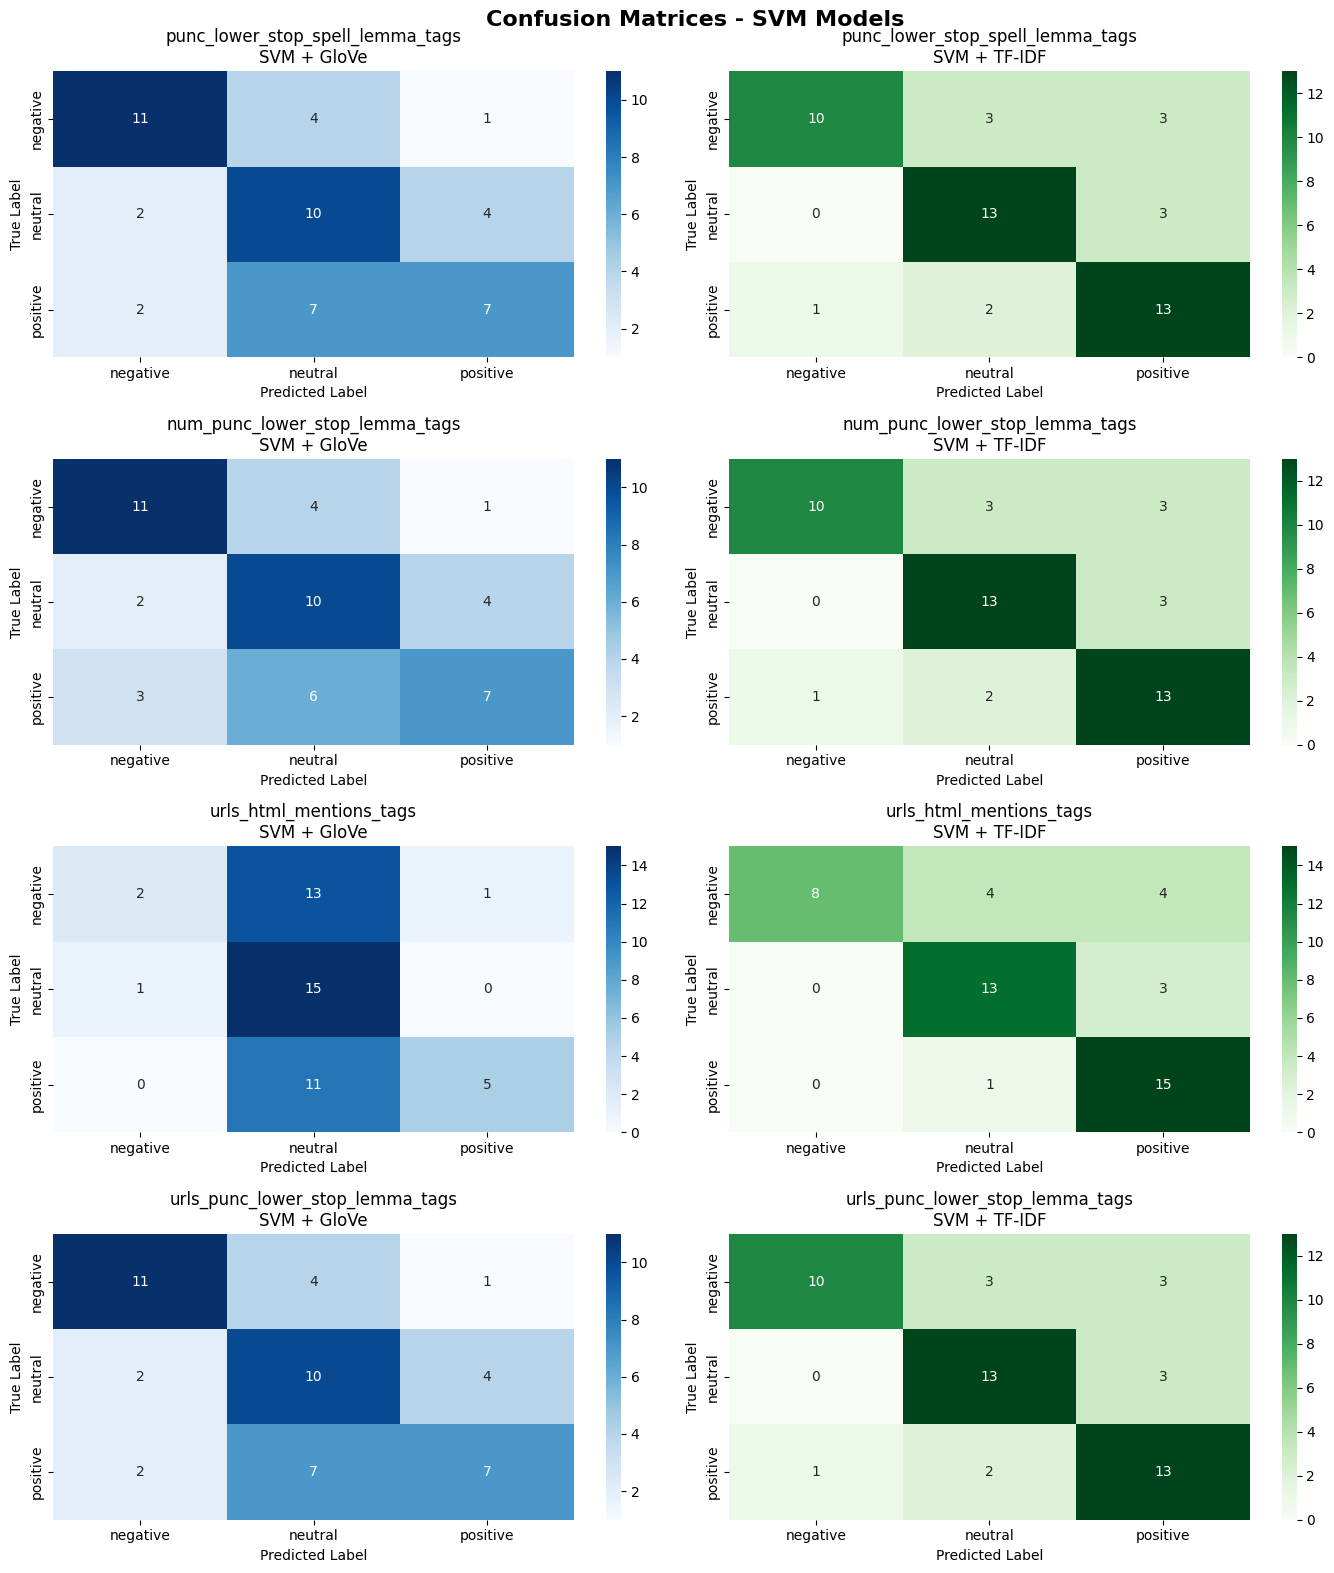


CONFUSION MATRICES - Linear Regression Models


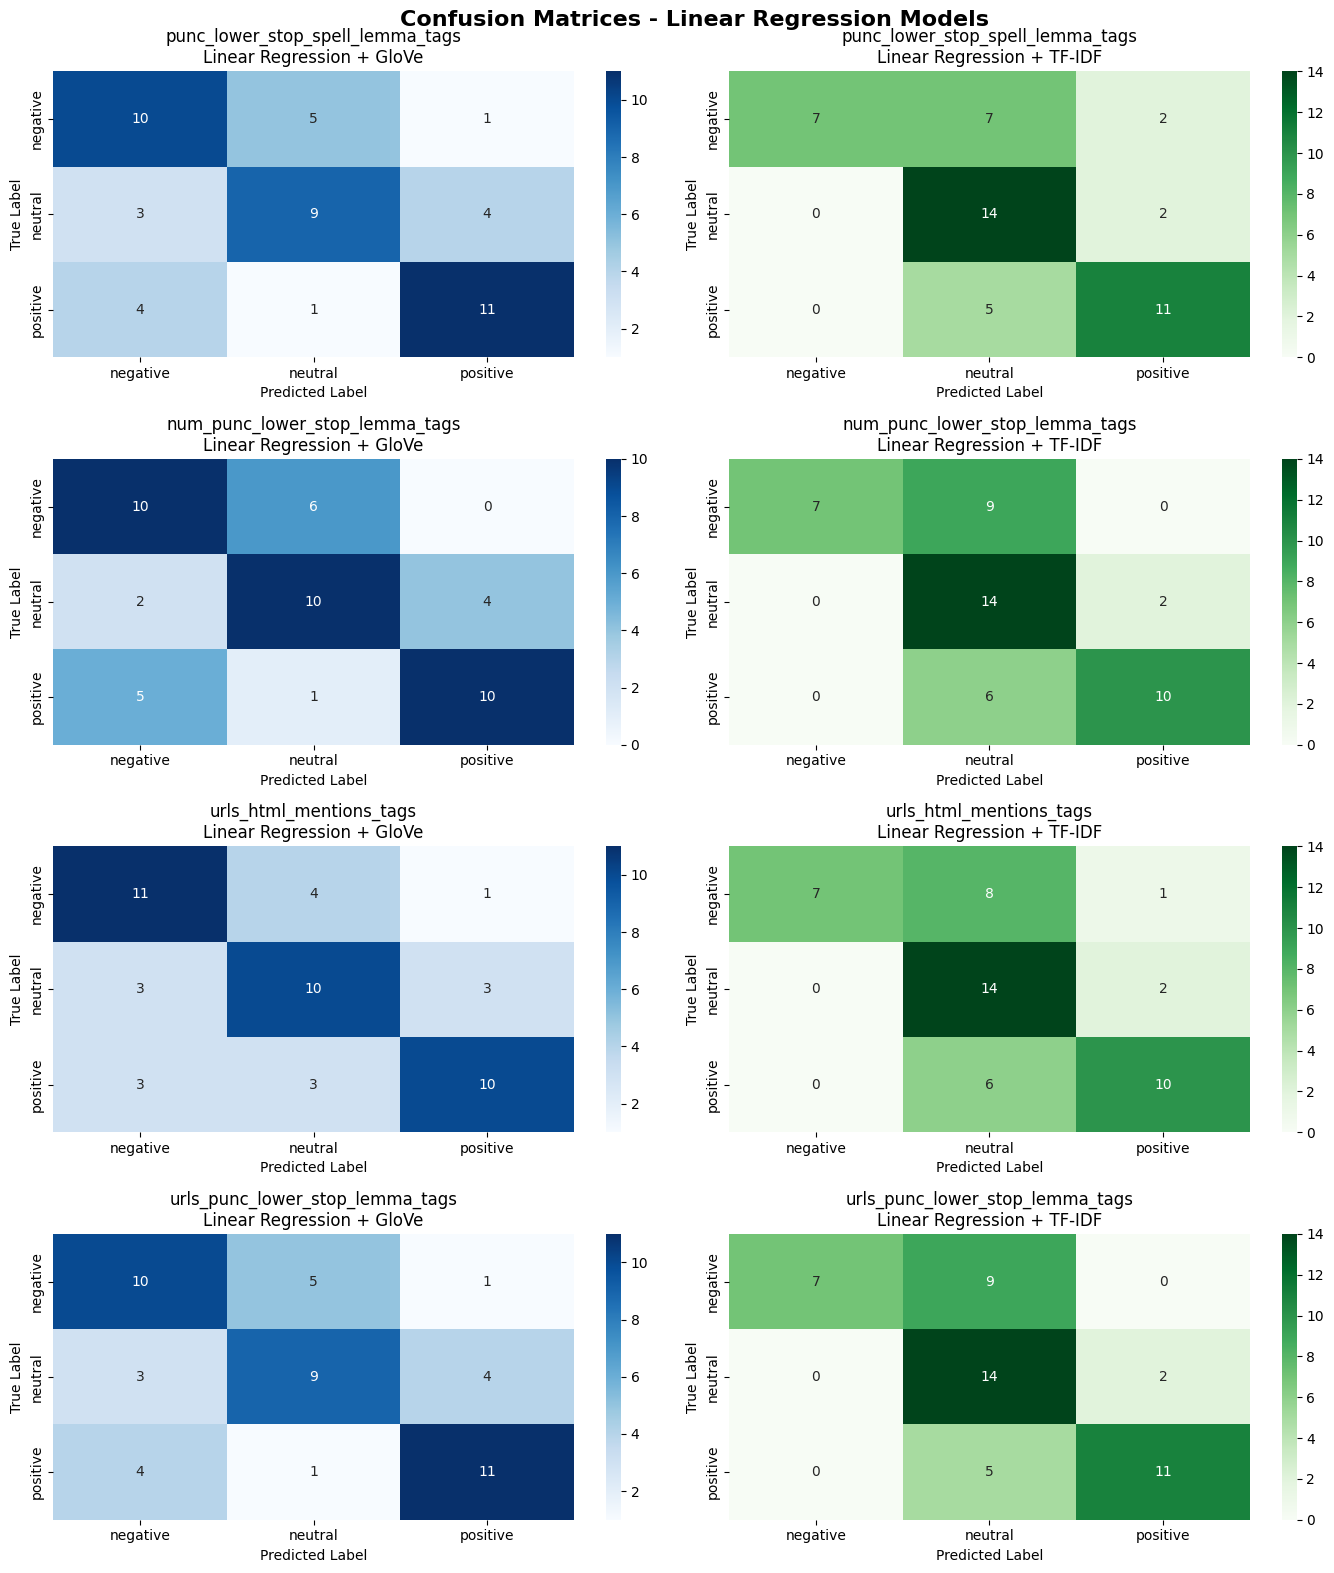


✓ Confusion matrices visualized for all models


In [18]:
# Visualize Confusion Matrices for SVM Models
print("="*80)
print("CONFUSION MATRICES - SVM Models")
print("="*80)

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
fig.suptitle('Confusion Matrices - SVM Models', fontsize=16, fontweight='bold')

dataset_list = list(data_splits.keys())
for idx, dataset_name in enumerate(dataset_list):
    reverse_mapping = data_splits[dataset_name]['reverse_mapping']
    labels = [reverse_mapping[i] for i in sorted(reverse_mapping.keys())]
    
    # GloVe
    cm_glove = svm_confusion_matrices[f'{dataset_name}_glove_svm']
    sns.heatmap(cm_glove, annot=True, fmt='d', cmap='Blues', ax=axes[idx, 0], 
                xticklabels=labels, yticklabels=labels, cbar=True)
    axes[idx, 0].set_title(f'{dataset_name}\nSVM + GloVe')
    axes[idx, 0].set_ylabel('True Label')
    axes[idx, 0].set_xlabel('Predicted Label')
    
    # TF-IDF
    cm_tfidf = svm_confusion_matrices[f'{dataset_name}_tfidf_svm']
    sns.heatmap(cm_tfidf, annot=True, fmt='d', cmap='Greens', ax=axes[idx, 1],
                xticklabels=labels, yticklabels=labels, cbar=True)
    axes[idx, 1].set_title(f'{dataset_name}\nSVM + TF-IDF')
    axes[idx, 1].set_ylabel('True Label')
    axes[idx, 1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

# Visualize Confusion Matrices for Linear Regression Models
print("\n" + "="*80)
print("CONFUSION MATRICES - Linear Regression Models")
print("="*80)

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
fig.suptitle('Confusion Matrices - Linear Regression Models', fontsize=16, fontweight='bold')

for idx, dataset_name in enumerate(dataset_list):
    reverse_mapping = data_splits[dataset_name]['reverse_mapping']
    labels = [reverse_mapping[i] for i in sorted(reverse_mapping.keys())]
    
    # GloVe
    cm_glove = lr_confusion_matrices[f'{dataset_name}_glove_lr']
    sns.heatmap(cm_glove, annot=True, fmt='d', cmap='Blues', ax=axes[idx, 0],
                xticklabels=labels, yticklabels=labels, cbar=True)
    axes[idx, 0].set_title(f'{dataset_name}\nLinear Regression + GloVe')
    axes[idx, 0].set_ylabel('True Label')
    axes[idx, 0].set_xlabel('Predicted Label')
    
    # TF-IDF
    cm_tfidf = lr_confusion_matrices[f'{dataset_name}_tfidf_lr']
    sns.heatmap(cm_tfidf, annot=True, fmt='d', cmap='Greens', ax=axes[idx, 1],
                xticklabels=labels, yticklabels=labels, cbar=True)
    axes[idx, 1].set_title(f'{dataset_name}\nLinear Regression + TF-IDF')
    axes[idx, 1].set_ylabel('True Label')
    axes[idx, 1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

print("\n✓ Confusion matrices visualized for all models")


COMPLETE MODEL PERFORMANCE SUMMARY - ALL 12 MODELS
                         Dataset                      Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC      MSE         R2
punc_lower_stop_spell_lemma_tags                SVM + GloVe  0.583333   0.597619 0.583333  0.583406 0.817057      NaN        NaN
punc_lower_stop_spell_lemma_tags               SVM + TF-IDF  0.750000   0.771841 0.750000  0.749435 0.904948      NaN        NaN
  num_punc_lower_stop_lemma_tags                SVM + GloVe  0.583333   0.590278 0.583333  0.581019 0.815104      NaN        NaN
  num_punc_lower_stop_lemma_tags               SVM + TF-IDF  0.750000   0.771841 0.750000  0.749435 0.910807      NaN        NaN
         urls_html_mentions_tags                SVM + GloVe  0.458333   0.628205 0.458333  0.403509 0.744141      NaN        NaN
         urls_html_mentions_tags               SVM + TF-IDF  0.750000   0.801347 0.750000  0.740282 0.918620      NaN        NaN
 urls_punc_lower_stop_lemma_tags             

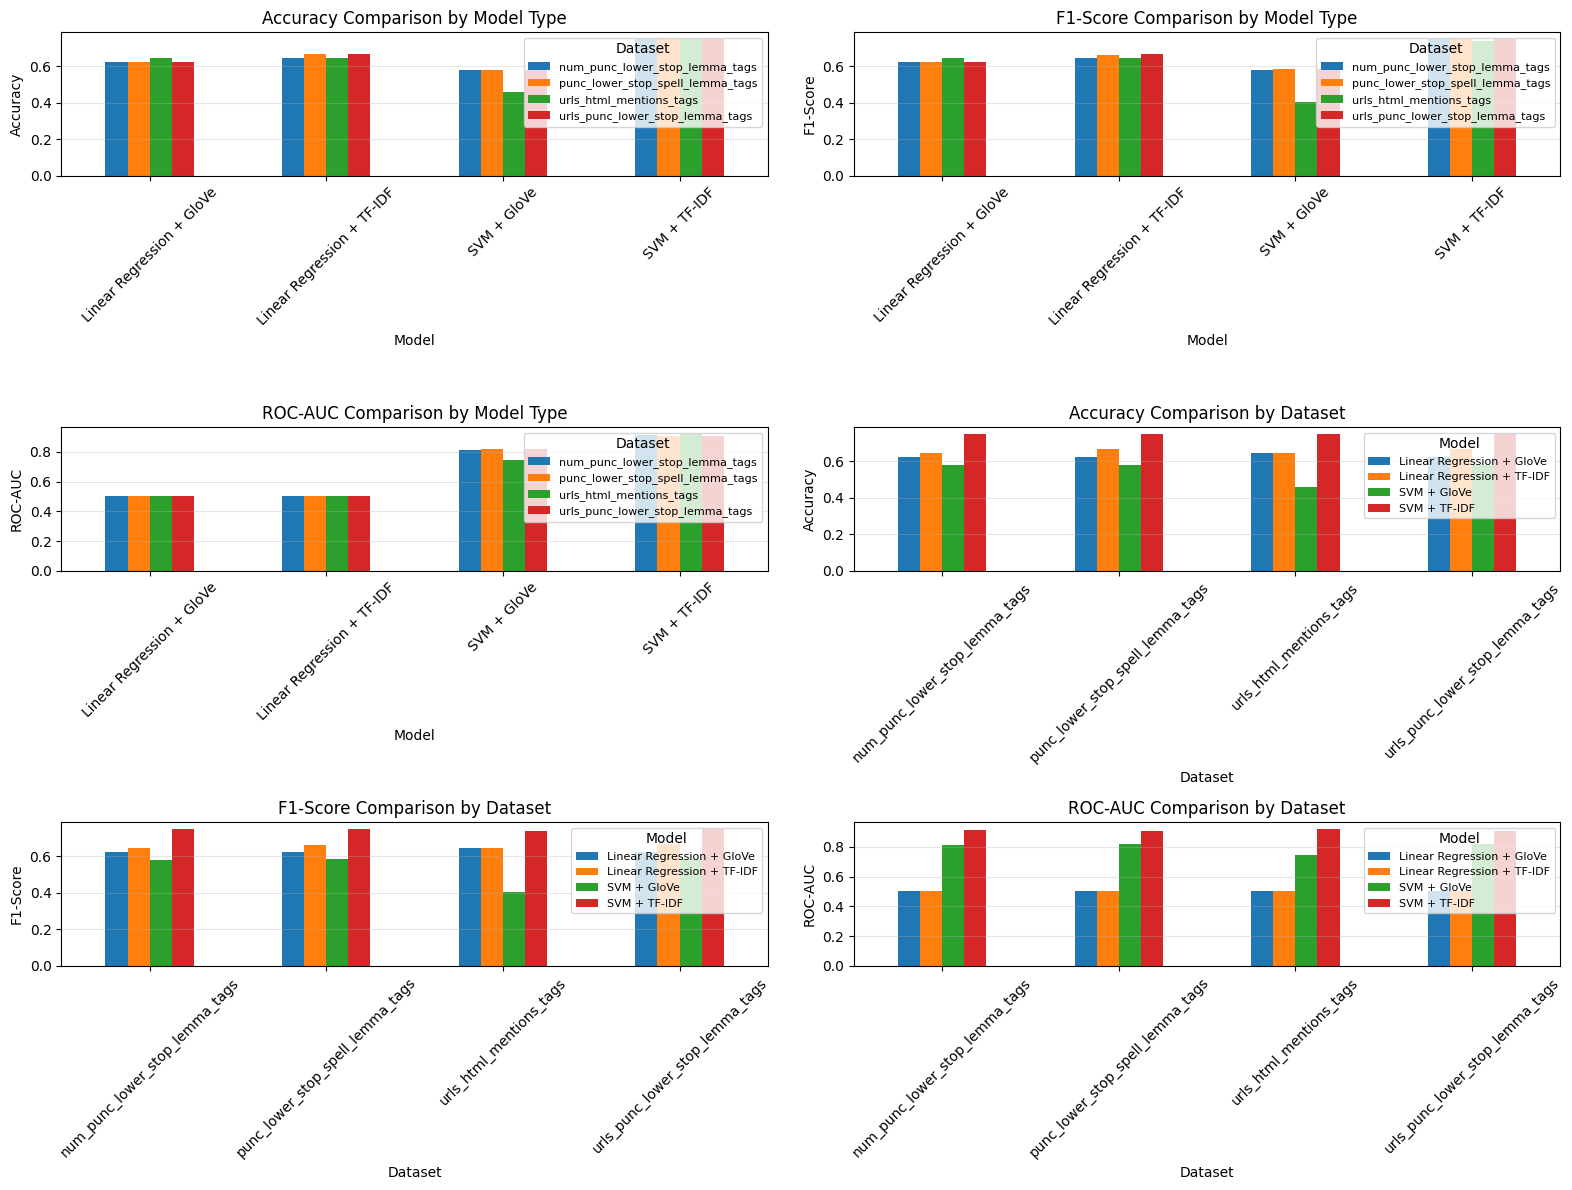


✓ All models evaluated and visualized with comprehensive metrics


In [19]:
# Combine all results
all_results = svm_results + lr_results
results_df = pd.DataFrame(all_results)

print("\n" + "="*80)
print("COMPLETE MODEL PERFORMANCE SUMMARY - ALL 12 MODELS")
print("="*80)
print(results_df.to_string(index=False))
print("="*80)

# Summary statistics (use only classification metrics for comparison)
classification_cols = ['Accuracy', 'F1-Score', 'ROC-AUC']
print("\nSummary by Model Type (Classification Metrics):")
model_summary = results_df.groupby('Model')[classification_cols].mean()
print(model_summary.round(4))

print("\nSummary by Dataset (Classification Metrics):")
dataset_summary = results_df.groupby('Dataset')[classification_cols].mean()
print(dataset_summary.round(4))

# Linear Regression specific metrics
print("\nLinear Regression - Regression Metrics (MSE & R²):")
lr_metrics = results_df[results_df['Model'].str.contains('Linear Regression')][['Dataset', 'Model', 'MSE', 'R2', 'ROC-AUC']]
print(lr_metrics.to_string(index=False))

# ROC-AUC Summary
print("\n" + "="*80)
print("ROC-AUC SCORES BY MODEL")
print("="*80)
roc_auc_summary = results_df[['Model', 'Dataset', 'ROC-AUC']].sort_values('ROC-AUC', ascending=False)
print(roc_auc_summary.to_string(index=False))

# Find best models
print("\n" + "="*80)
print("BEST MODELS")
print("="*80)
best_accuracy_idx = results_df['Accuracy'].idxmax()
best_f1_idx = results_df['F1-Score'].idxmax()
best_roc_auc_idx = results_df['ROC-AUC'].idxmax()

print(f"\nBest by Accuracy:")
print(results_df.iloc[best_accuracy_idx])

print(f"\nBest by F1-Score:")
print(results_df.iloc[best_f1_idx])

print(f"\nBest by ROC-AUC:")
print(results_df.iloc[best_roc_auc_idx])

# Create comparison visualizations (6 plots now)
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

# Plot 1: Accuracy by Model
ax1 = axes[0, 0]
results_pivot = results_df.pivot(index='Model', columns='Dataset', values='Accuracy')
results_pivot.plot(kind='bar', ax=ax1)
ax1.set_title('Accuracy Comparison by Model Type')
ax1.set_ylabel('Accuracy')
ax1.legend(title='Dataset', fontsize=8)
ax1.grid(axis='y', alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Plot 2: F1-Score by Model
ax2 = axes[0, 1]
results_pivot_f1 = results_df.pivot(index='Model', columns='Dataset', values='F1-Score')
results_pivot_f1.plot(kind='bar', ax=ax2)
ax2.set_title('F1-Score Comparison by Model Type')
ax2.set_ylabel('F1-Score')
ax2.legend(title='Dataset', fontsize=8)
ax2.grid(axis='y', alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

# Plot 3: ROC-AUC by Model
ax3 = axes[1, 0]
results_pivot_roc = results_df.pivot(index='Model', columns='Dataset', values='ROC-AUC')
results_pivot_roc.plot(kind='bar', ax=ax3)
ax3.set_title('ROC-AUC Comparison by Model Type')
ax3.set_ylabel('ROC-AUC')
ax3.legend(title='Dataset', fontsize=8)
ax3.grid(axis='y', alpha=0.3)
ax3.tick_params(axis='x', rotation=45)

# Plot 4: Accuracy by Dataset
ax4 = axes[1, 1]
dataset_pivot = results_df.pivot(index='Dataset', columns='Model', values='Accuracy')
dataset_pivot.plot(kind='bar', ax=ax4)
ax4.set_title('Accuracy Comparison by Dataset')
ax4.set_ylabel('Accuracy')
ax4.legend(title='Model', fontsize=8)
ax4.grid(axis='y', alpha=0.3)
ax4.tick_params(axis='x', rotation=45)

# Plot 5: F1-Score by Dataset
ax5 = axes[2, 0]
dataset_pivot_f1 = results_df.pivot(index='Dataset', columns='Model', values='F1-Score')
dataset_pivot_f1.plot(kind='bar', ax=ax5)
ax5.set_title('F1-Score Comparison by Dataset')
ax5.set_ylabel('F1-Score')
ax5.legend(title='Model', fontsize=8)
ax5.grid(axis='y', alpha=0.3)
ax5.tick_params(axis='x', rotation=45)

# Plot 6: ROC-AUC by Dataset
ax6 = axes[2, 1]
dataset_pivot_roc = results_df.pivot(index='Dataset', columns='Model', values='ROC-AUC')
dataset_pivot_roc.plot(kind='bar', ax=ax6)
ax6.set_title('ROC-AUC Comparison by Dataset')
ax6.set_ylabel('ROC-AUC')
ax6.legend(title='Model', fontsize=8)
ax6.grid(axis='y', alpha=0.3)
ax6.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n✓ All models evaluated and visualized with comprehensive metrics")

## 8. Model Storage & Summary

In [20]:
import pickle
import json
from datetime import datetime

# Save results to CSV
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
results_df.to_csv(f'model_results_{timestamp}.csv', index=False)
print(f"Results saved to: model_results_{timestamp}.csv")

# Create comprehensive summary
summary = {
    'total_models': len(svm_models) + len(lr_models),
    'datasets_used': list(data_splits.keys()),
    'text_representations': ['GloVe (300d)', 'TF-IDF'],
    'classifiers': ['SVM', 'Linear Regression'],
    'timestamp': timestamp,
    'glove_file': 'glove.6B.300d',
    'best_model_by_accuracy': {
        'model_name': results_df.iloc[best_accuracy_idx]['Model'],
        'dataset': results_df.iloc[best_accuracy_idx]['Dataset'],
        'accuracy': float(results_df.iloc[best_accuracy_idx]['Accuracy'])
    },
    'best_model_by_f1': {
        'model_name': results_df.iloc[best_f1_idx]['Model'],
        'dataset': results_df.iloc[best_f1_idx]['Dataset'],
        'f1_score': float(results_df.iloc[best_f1_idx]['F1-Score'])
    },
    'model_details': results_df.to_dict('records')
}

# Save summary to JSON
with open(f'model_summary_{timestamp}.json', 'w') as f:
    json.dump(summary, f, indent=4)
print(f"Summary saved to: model_summary_{timestamp}.json")

# Print final summary
print("\n" + "="*80)
print("TRAINING SUMMARY")
print("="*80)
print(f"✓ Total Models Trained: {summary['total_models']}")
print(f"✓ Datasets Used: {', '.join(summary['datasets_used'])}")
print(f"✓ Text Representations: {', '.join(summary['text_representations'])}")
print(f"✓ Classifiers: {', '.join(summary['classifiers'])}")
print(f"✓ GloVe File: {summary['glove_file']}")
print(f"\n✓ Best Model (Accuracy): {summary['best_model_by_accuracy']['model_name']}")
print(f"   Dataset: {summary['best_model_by_accuracy']['dataset']}")
print(f"   Accuracy: {summary['best_model_by_accuracy']['accuracy']:.4f}")
print(f"\n✓ Best Model (F1-Score): {summary['best_model_by_f1']['model_name']}")
print(f"   Dataset: {summary['best_model_by_f1']['dataset']}")
print(f"   F1-Score: {summary['best_model_by_f1']['f1_score']:.4f}")
print("="*80)

print("\nTrained Models Dictionary:")
print(f"  SVM Models: {list(svm_models.keys())}")
print(f"  Linear Regression Models: {list(lr_models.keys())}")

print("\n✓ All models trained, evaluated, and documented!")

Results saved to: model_results_20260425_004246.csv
Summary saved to: model_summary_20260425_004246.json

TRAINING SUMMARY
✓ Total Models Trained: 16
✓ Datasets Used: punc_lower_stop_spell_lemma_tags, num_punc_lower_stop_lemma_tags, urls_html_mentions_tags, urls_punc_lower_stop_lemma_tags
✓ Text Representations: GloVe (300d), TF-IDF
✓ Classifiers: SVM, Linear Regression
✓ GloVe File: glove.6B.300d

✓ Best Model (Accuracy): SVM + TF-IDF
   Dataset: punc_lower_stop_spell_lemma_tags
   Accuracy: 0.7500

✓ Best Model (F1-Score): SVM + TF-IDF
   Dataset: punc_lower_stop_spell_lemma_tags
   F1-Score: 0.7494

Trained Models Dictionary:
  SVM Models: ['punc_lower_stop_spell_lemma_tags_glove_svm', 'punc_lower_stop_spell_lemma_tags_tfidf_svm', 'num_punc_lower_stop_lemma_tags_glove_svm', 'num_punc_lower_stop_lemma_tags_tfidf_svm', 'urls_html_mentions_tags_glove_svm', 'urls_html_mentions_tags_tfidf_svm', 'urls_punc_lower_stop_lemma_tags_glove_svm', 'urls_punc_lower_stop_lemma_tags_tfidf_svm']
  Li

In [22]:
#ُ OPTIMIZATION
# SELECT BEST DATASET + FEATURES

best_dataset = 'punc_lower_stop_spell_lemma_tags'

X_train_glove = glove_representations[best_dataset]['X_train']
X_test_glove = glove_representations[best_dataset]['X_test']

X_train_tfidf = tfidf_representations[best_dataset]['X_train']
X_test_tfidf = tfidf_representations[best_dataset]['X_test']

y_train = data_splits[best_dataset]['y_train']
y_test = data_splits[best_dataset]['y_test']

In [25]:
#BASELINE (BEFORE OPTIMIZATION)
baseline_f1 = results_df[
    (results_df['Dataset'] == best_dataset) & 
    (results_df['Model'] == 'SVM + TF-IDF')
]['F1-Score'].values[0]

print("Baseline F1 (SVM + TF-IDF):", baseline_f1)

Baseline F1 (SVM + TF-IDF): 0.7494345886502748


In [26]:
#OPTIMIZE SVM (MAIN PART)
param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],  # required by assignment
    'gamma': ['scale', 'auto'],
    'class_weight': [None, 'balanced']
}

grid_svm = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid_svm,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

grid_svm.fit(X_train_glove, y_train)

best_svm = grid_svm.best_estimator_

print("Best SVM Params:", grid_svm.best_params_)

Best SVM Params: {'C': 10, 'class_weight': None, 'gamma': 'scale', 'kernel': 'linear'}


In [27]:
#Evaluate optimized SVM
y_pred_svm_opt = best_svm.predict(X_test_glove)

f1_svm_opt = f1_score(y_test, y_pred_svm_opt, average='weighted')
acc_svm_opt = accuracy_score(y_test, y_pred_svm_opt)

print("\nOptimized SVM Results:")
print("F1:", f1_svm_opt)
print("Accuracy:", acc_svm_opt)
print(classification_report(y_test, y_pred_svm_opt))


Optimized SVM Results:
F1: 0.7518993648025907
Accuracy: 0.75
              precision    recall  f1-score   support

           0       0.87      0.81      0.84        16
           1       0.83      0.62      0.71        16
           2       0.62      0.81      0.70        16

    accuracy                           0.75        48
   macro avg       0.77      0.75      0.75        48
weighted avg       0.77      0.75      0.75        48



In [28]:
#REPLACE LINEAR REGRESSION → LOGISTIC REGRESSION
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear'],
    'class_weight': [None, 'balanced']
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid_lr,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

grid_lr.fit(X_train_tfidf, y_train)

best_lr = grid_lr.best_estimator_

print("Best Logistic Regression Params:", grid_lr.best_params_)

Best Logistic Regression Params: {'C': 1, 'class_weight': None, 'solver': 'lbfgs'}


In [29]:
#Evaluate Logistic Regression
y_pred_lr_opt = best_lr.predict(X_test_tfidf)

f1_lr_opt = f1_score(y_test, y_pred_lr_opt, average='weighted')

print("\nOptimized Logistic Regression Results:")
print("F1:", f1_lr_opt)
print(classification_report(y_test, y_pred_lr_opt))


Optimized Logistic Regression Results:
F1: 0.7721500721500721
              precision    recall  f1-score   support

           0       0.92      0.69      0.79        16
           1       0.76      0.81      0.79        16
           2       0.68      0.81      0.74        16

    accuracy                           0.77        48
   macro avg       0.79      0.77      0.77        48
weighted avg       0.79      0.77      0.77        48



In [30]:
#BEFORE vs AFTER
comparison_df = pd.DataFrame({
    'Model': ['SVM Before', 'SVM After'],
    'F1 Score': [baseline_f1, f1_svm_opt]
})

print("\nMODEL COMPARISON:")
print(comparison_df)


MODEL COMPARISON:
        Model  F1 Score
0  SVM Before  0.749435
1   SVM After  0.751899


In [31]:
#check 20% improvement
random_f1 = 0.5

improvement = ((f1_svm_opt - random_f1) / random_f1) * 100

print("\nImprovement over random (%):", improvement)


Improvement over random (%): 50.379872960518135


In [39]:
best_row = results_df.iloc[best_accuracy_idx]

best_model_readable = best_row['Model']
best_dataset = best_row['Dataset']

print("Best Model (readable):", best_model_readable)
print("Best Dataset:", best_dataset)


Best Model (readable): SVM + TF-IDF
Best Dataset: punc_lower_stop_spell_lemma_tags


In [40]:
print("\nAvailable SVM Models:")
for key in sorted(svm_models.keys()):
    print(f"  {key}")



Available SVM Models:
  num_punc_lower_stop_lemma_tags_glove_svm
  num_punc_lower_stop_lemma_tags_tfidf_svm
  punc_lower_stop_spell_lemma_tags_glove_svm
  punc_lower_stop_spell_lemma_tags_tfidf_svm
  urls_html_mentions_tags_glove_svm
  urls_html_mentions_tags_tfidf_svm
  urls_punc_lower_stop_lemma_tags_glove_svm
  urls_punc_lower_stop_lemma_tags_tfidf_svm


In [41]:
# Extract representation type from model name
if 'GloVe' in best_model_readable:
    representation = 'glove_svm'
    X_test_features = glove_representations[best_dataset]['X_test']
elif 'TF-IDF' in best_model_readable:
    representation = 'tfidf_svm'
    X_test_features = tfidf_representations[best_dataset]['X_test']
else:
    print("Error: Could not determine representation type")
    representation = None

# Construct the full model key
best_model_key = f"{best_dataset}_{representation}"

print(f"\nConstructed model key: {best_model_key}")
print(f"Representation: {'GloVe (100 features)' if 'glove' in representation else 'TF-IDF (1000 features)' if representation else 'Unknown'}")

if best_model_key in svm_models:
    best_model = svm_models[best_model_key]
    print("✓ Model found successfully")
else:
    print(f"✗ Error: Model key '{best_model_key}' not found in svm_models")
    best_model = None



Constructed model key: punc_lower_stop_spell_lemma_tags_tfidf_svm
Representation: TF-IDF (1000 features)
✓ Model found successfully


In [42]:
if best_model is not None:
    y_test = data_splits[best_dataset]['y_test']
    y_pred = best_model['model'].predict(X_test_features)
    print(f"✓ Predictions generated successfully")
    print(f"  X_test shape: {X_test_features.shape}")
    print(f"  Predictions shape: {y_pred.shape}")
else:
    print("✗ Cannot make predictions: best_model is None")
    y_pred = None
    y_test = None


✓ Predictions generated successfully
  X_test shape: (48, 1000)
  Predictions shape: (48,)


In [43]:
if y_pred is not None and y_test is not None:
    errors_df = pd.DataFrame({
        "text": data_splits[best_dataset]['X_test'],
        "true_label": y_test,
        "pred_label": y_pred
    })

    wrong_predictions = errors_df[errors_df["true_label"] != errors_df["pred_label"]]

    print("Errors:", len(wrong_predictions))
else:
    print("✗ Cannot create error analysis: predictions were not generated")


Errors: 12


In [44]:
if 'wrong_predictions' in locals() and len(wrong_predictions) > 0:
    error_rate = len(wrong_predictions) / len(errors_df)
    print("Error Rate:", round(error_rate, 4))
    print("Accuracy:", round(1 - error_rate, 4))
else:
    print("✗ No error analysis available")


Error Rate: 0.25
Accuracy: 0.75


In [45]:
if 'wrong_predictions' in locals() and len(wrong_predictions) > 0:
    wrong_predictions.groupby(["true_label", "pred_label"]).size().sort_values(ascending=False)
else:
    print("✗ No error breakdown available")


In [46]:
if 'wrong_predictions' in locals() and len(wrong_predictions) > 0:
    wrong_predictions.sample(min(6, len(wrong_predictions)), random_state=42)
else:
    print("✗ No prediction errors to sample")


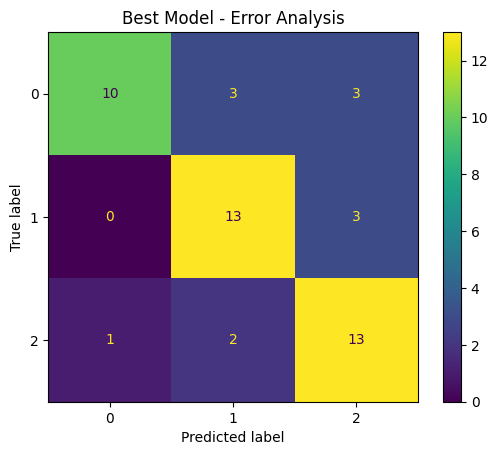

In [47]:
if y_pred is not None and y_test is not None:
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title("Best Model - Error Analysis")
    plt.show()
else:
    print("✗ Cannot generate confusion matrix: predictions not available")


In [48]:
if 'wrong_predictions' in locals() and len(wrong_predictions) > 0:
    wrong_predictions[["text", "true_label", "pred_label"]].head(20)
else:
    print("✗ No prediction errors to display")


In [ ]:
#Error Analysis Insight:

## The model struggles with long and sarcastic reviews, especially those containing mixed sentiments and complex narrative structures.
## Most misclassifications occur between adjacent sentiment classes, indicating difficulty in capturing sentiment intensity rather than polarity.

In [49]:
## Save Optimized Model for Deployment

import pickle
import json
import os
from datetime import datetime

# Use the dynamically selected best model
if best_model is not None and best_model_key is not None:
    # Best Model Information
    best_model_obj = best_model['model']
    best_dataset_name = best_dataset
    
    # Get the correct representations based on model type
    if 'glove' in best_model_key:
        best_repr_dict = glove_representations[best_dataset_name]
        representation_type = 'GloVe'
        embedding_dim = 100
    else:  # tfidf
        best_repr_dict = tfidf_representations[best_dataset_name]
        representation_type = 'TF-IDF'
        embedding_dim = 1000
    
    best_data_split = data_splits[best_dataset_name]

    # Create deployment package
    deployment_package = {
        'model': best_model_obj,
        'model_key': best_model_key,
        'label_mapping': best_data_split['label_mapping'],
        'reverse_mapping': best_data_split['reverse_mapping'],
        'model_type': 'SVM',
        'representation': representation_type,
        'embedding_dim': embedding_dim,
        'dataset': best_dataset_name,
        'timestamp': datetime.now().strftime("%Y%m%d_%H%M%S")
    }
    
    # Add representation-specific data
    if 'glove' in best_model_key:
        deployment_package['glove_embeddings'] = best_repr_dict['embeddings_index']
    else:
        deployment_package['vectorizer'] = best_repr_dict['vectorizer']
        deployment_package['scaler'] = best_repr_dict['scaler']

    # Save as pickle file
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    model_pkl_file = f'best_model_svm_{representation_type.lower()}_{timestamp}.pkl'

    with open(model_pkl_file, 'wb') as f:
        pickle.dump(deployment_package, f)

    print(f"✓ Model saved successfully!")
    print(f"  File: {model_pkl_file}")
    print(f"  Size: {os.path.getsize(model_pkl_file) / (1024**2):.2f} MB")
    print(f"  Model Type: {best_model_key}")
    print(f"  Representation: {representation_type}")
    print(f"  Dataset: {best_dataset_name}")

    # Create a metadata JSON file for reference
    best_results = results_df[results_df['Dataset'] == best_dataset_name]
    best_model_results = best_results[best_results['Model'] == best_model_readable].iloc[0]
    
    metadata = {
        'model_file': model_pkl_file,
        'model_name': best_model_key,
        'dataset': best_dataset_name,
        'model_type': 'SVM (Support Vector Machine)',
        'text_representation': f'{representation_type}',
        'embedding_dim': embedding_dim,
        'classes': list(best_data_split['reverse_mapping'].values()),
        'label_mapping': best_data_split['label_mapping'],
        'performance_metrics': {
            'accuracy': float(best_model_results['Accuracy']),
            'precision': float(best_model_results['Precision']),
            'recall': float(best_model_results['Recall']),
            'f1_score': float(best_model_results['F1-Score']),
            'roc_auc': float(best_model_results['ROC-AUC'])
        },
        'created_date': datetime.now().isoformat()
    }

    metadata_json_file = f'model_metadata_{timestamp}.json'
    with open(metadata_json_file, 'w') as f:
        json.dump(metadata, f, indent=4)

    print(f"\n✓ Metadata file created!")
    print(f"  File: {metadata_json_file}")

    # Print model summary
    print(f"\n{'='*80}")
    print(f"DEPLOYMENT SUMMARY")
    print(f"{'='*80}")
    print(f"Model: {best_model_readable}")
    print(f"Dataset: {best_dataset_name}")
    print(f"Representation: {representation_type} ({embedding_dim} features)")
    print(f"\nPerformance:")
    print(f"  Accuracy:  {metadata['performance_metrics']['accuracy']:.4f}")
    print(f"  Precision: {metadata['performance_metrics']['precision']:.4f}")
    print(f"  Recall:    {metadata['performance_metrics']['recall']:.4f}")
    print(f"  F1-Score:  {metadata['performance_metrics']['f1_score']:.4f}")
    print(f"  ROC-AUC:   {metadata['performance_metrics']['roc_auc']:.4f}")
    print(f"\nClasses: {list(best_data_split['reverse_mapping'].values())}")
    print(f"{'='*80}")
else:
    print("✗ Cannot save model: best_model is not defined")


✓ Model saved successfully!
  File: best_model_svm_tf-idf_20260425_005302.pkl
  Size: 0.15 MB
  Model Type: punc_lower_stop_spell_lemma_tags_tfidf_svm
  Representation: TF-IDF
  Dataset: punc_lower_stop_spell_lemma_tags

✓ Metadata file created!
  File: model_metadata_20260425_005302.json

DEPLOYMENT SUMMARY
Model: SVM + TF-IDF
Dataset: punc_lower_stop_spell_lemma_tags
Representation: TF-IDF (1000 features)

Performance:
  Accuracy:  0.7500
  Precision: 0.7718
  Recall:    0.7500
  F1-Score:  0.7494
  ROC-AUC:   0.9049

Classes: ['negative', 'neutral', 'positive']


In [50]:
## Verify Deployment Files

import glob

print("\n" + "="*80)
print("DEPLOYMENT FILES VERIFICATION")
print("="*80)

# Find all deployment-related files
pkl_files = glob.glob('best_model_svm_*.pkl')
json_files = glob.glob('model_metadata_*.json')

if pkl_files:
    print(f"\n✓ Model Files (.pkl):")
    for file in sorted(pkl_files, reverse=True)[:3]:  # Show last 3
        size_mb = os.path.getsize(file) / (1024**2)
        print(f"  └─ {file} ({size_mb:.2f} MB)")
else:
    print("\n✗ No model files found")

if json_files:
    print(f"\n✓ Metadata Files (.json):")
    for file in sorted(json_files, reverse=True)[:3]:  # Show last 3
        size_kb = os.path.getsize(file) / 1024
        print(f"  └─ {file} ({size_kb:.2f} KB)")
else:
    print("\n✗ No metadata files found")

print(f"\n" + "="*80)
if pkl_files and json_files:
    print("✓ READY FOR DEPLOYMENT!")
    print("="*80)
    print("\nNext Steps:")
    print("1. Use the most recent .pkl file in your deployment code")
    print("2. Reference the corresponding metadata .json for model configuration")
    print("3. Load model with: model_pkg = pickle.load(open('model_file.pkl', 'rb'))")
else:
    print("✗ DEPLOYMENT FILES INCOMPLETE")
    print("="*80)
    print("Please run the model save cell first")
    
print("\n" + "="*80)



DEPLOYMENT FILES VERIFICATION

✓ Model Files (.pkl):
  └─ best_model_svm_tf-idf_20260425_005302.pkl (0.15 MB)
  └─ best_model_svm_glove_20260418_042431.pkl (169.23 MB)

✓ Metadata Files (.json):
  └─ model_metadata_20260425_005302.json (0.74 KB)

✓ READY FOR DEPLOYMENT!

Next Steps:
1. Use the most recent .pkl file in your deployment code
2. Reference the corresponding metadata .json for model configuration
3. Load model with: model_pkg = pickle.load(open('model_file.pkl', 'rb'))

